# 1. request 모듈 : HTTP프로토콜을 사용할 있게 해 주는 모듈
* requests 모듈 사용설명서
[requests](https://requests.readthedocs.io/en/latest/)<br>
(Quick Start 참고)

# 2. requests 모듈 설치
* conda install requests
* pip install requests

# 3. requests 모듈 사용법

* 1) 모듈 불러오기: import requests
* 2) url 변수에 저장
* 3) url 파라미터
  * payload = {파라미터1 : value, 파라미터2 : value} 
* 4) header
  * headers = {key : value}
* 5) HTTP 요청 보내기 get, post
  * get: r = requests.get(url, params=payload, headers=headers)
  * post: r = requests.post(url, data={key:value})
* 6) 만들어진 url 확인: print(r.url)
* 7) 응답 코드 확인: print(r.status_code)
* 8) 응답 요소 출력: r.text, r.content, r.json()

# requests 코드 외워두자

In [3]:
import requests
url = "https://openapi.naver.com/v1/search/book.json"
payload = dict()
r = requests.get(url, params=payload)
print(r.url)
print(r.status_code)
response = r.json # r.content r.text

https://openapi.naver.com/v1/search/book.json
400


# requests 모듈로 1페이지만 가져오기

In [6]:
start_num2 = 1
for s_num in range(10):
    if start_num2 < 901:
        print(start_num2)
        start_num2 += 100
    elif start_num2 == 901:
        print(start_num2)
        start_num2 += 99
        print(start_num2)

1
101
201
301
401
501
601
701
801
901
1000


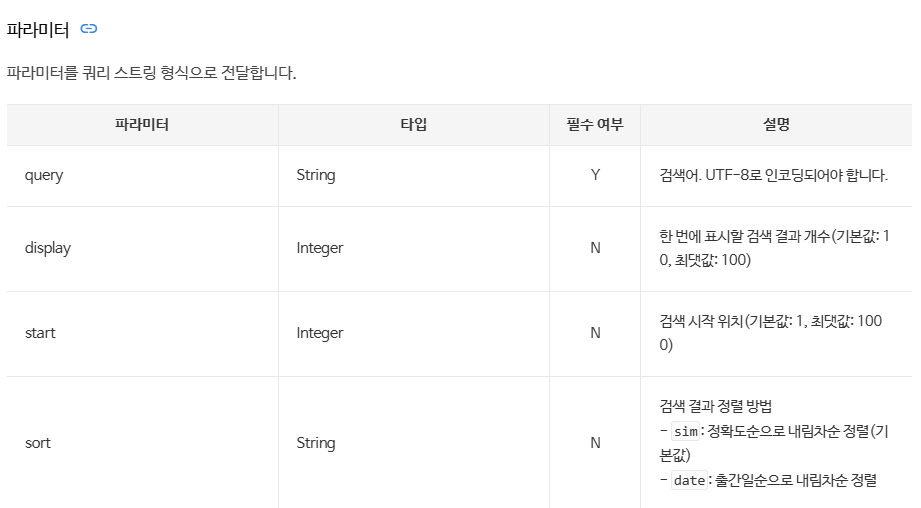

In [7]:
url = "https://openapi.naver.com/v1/search/book.json"
Client_Id = "sk2iKdMANqpvG3Pa2WIJ"
Client_Secret = "by6xHZcrlB"
payload = dict(query="핀테크", display=100, start=start_num, sort="sim")
headers = {"X-Naver-Client-Id": Client_Id,
           "X-Naver-Client-Secret": Client_Secret}
r = requests.get(url, params=payload, headers=headers)
print(r.url)
print(r.status_code)
response = r.json()

https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=1000&sort=sim
200


In [10]:
import requests
start_num = 1
result_json = []
for page in range(11):
    print(start_num)
    url = "https://openapi.naver.com/v1/search/blog.json"
    Client_Id = "_kWwMseeAybz6oDQo3EC"
    Client_Secret = "oWRhEifFRY"
    payload = dict(query="핀테크", display=100, start = start_num, sort="sim")
    headers = {"X-Naver-Client-Id": Client_Id,
               "X-Naver-Client-Secret": Client_Secret}
    r = requests.get(url, params=payload, headers=headers)
    print(r.url)
    print(r.status_code)
    response = r.json()
    result_json.append(response)
    if start_num < 901:
        start_num += 100
    elif start_num == 901:
        start_num += 99

1
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=1&sort=sim
200
101
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=101&sort=sim
200
201
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=201&sort=sim
200
301
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=301&sort=sim
200
401
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=401&sort=sim
200
501
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=501&sort=sim
200
601
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=601&sort=sim
200
701
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=701&sort=sim
200
801
https://openapi.naver.com/v1/search/blog.json?qu

* 모든 검색결과를 가져오기 위해서는 여러 페이지 정보를 수집
* 전체 결과 // 1페이지 표시 개수 + 1 = 전체 페이지수
* start 부분 + 1페이지 표시 개수 = 다음 페이지 데이터 수집 가능
* 반복문을 이용해서 start에 100씩 더해서 최대 1000이 되도록 하면 최대한 많은 데이터 수집 가능

In [13]:
result_json[0]['total'] // result_json[0]['display'] + 1

4580

In [14]:
result_json[0]

{'lastBuildDate': 'Fri, 11 Apr 2025 22:21:06 +0900',
 'total': 457901,
 'start': 1,
 'display': 100,
 'items': [{'title': '<b>핀테크</b>대출 직접 써보니 유용했어요',
   'link': 'https://blog.naver.com/fdgbrhyjg_1/223828503185',
   'description': '바로 <b>핀테크</b>대출이에요. 처음 들어보셨다면, 이제 하나씩 알아가 보도록 할게요. 이 글에서는 제 경험을 포함해서 뜻과 장점, 단점, 그리고 후기와 추천 팁까지 모두 다뤄볼 거예요. <b>핀테크</b>대출이란 무엇일까요?... ',
   'bloggername': '✅ 자동차 공식 인증 Blog',
   'bloggerlink': 'blog.naver.com/fdgbrhyjg_1',
   'postdate': '20250410'},
  {'title': '[정책현장] 금융회사와 <b>핀테크</b>의 협업을 지원합니다',
   'link': 'https://blog.naver.com/blogfsc/223828700585',
   'description': '김병환 금융위원장은 금융회사와 <b>핀테크</b>의 협업을 위해 마련된 [제3회 <b>핀테크</b> 오픈 네트워킹 데이] 행사에 참석하였습니다. ✔ 금융지주의 <b>핀테크</b> 출자·소유 관련 규제 완화 추진 ✔ <b>핀테크</b> 구성원의... ',
   'bloggername': '금융위원회 공식 블로그',
   'bloggerlink': 'blog.naver.com/blogfsc',
   'postdate': '20250410'},
  {'title': '[인사이트 캠퍼스X새싹 종로캠] 실무 요건 기반 <b>핀테크</b> 데이터... ',
   'link': 'https://blog.naver.com/fininsight/223829922172',
   'description': '안녕하

# 정모르겠다면?

In [16]:
pages = response['total'] // response['display'] + 1
# 457862 // 100 + 1

In [17]:
pages

4580

In [92]:
# 쉽게 가보자 (내 수준)

pages = response['total'] // response['display'] + 1 # 4580
start_num = 1
response_json2 = []
for page in range(pages):
    url = "https://openapi.naver.com/v1/search/book.json"
    Client_Id = "_kWwMseeAybz6oDQo3EC"
    Client_Secret = "oWRhEifFRY"
    payload = dict(query="핀테크", display=100, start = start_num, sort="sim")
    headers = {"X-Naver-Client-Id": Client_Id,
           "X-Naver-Client-Secret": Client_Secret}
    r = requests.get(url, params=payload, headers=headers)
    print(r.url)
    print(r.status_code)
    response = r.json()
    response_json2.append(response)
    if start_num == 1000:
        break
    if start_num < 901:
        start_num += 100
    elif start_num == 901:
        start_num += 99

https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=1&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=101&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=201&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=301&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=401&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=501&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=601&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=701&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&di

In [ ]:
response_json2 = []
for category2 in ['blog', 'news', 'book']:
    start_num = 1
    for page in range(pages): #page = 4580
        url = f"https://openapi.naver.com/v1/search/{category2}.json"
        Client_Id = "_kWwMseeAybz6oDQo3EC"
        Client_Secret = "oWRhEifFRY"
        payload = dict(query="핀테크", display=100, start = start_num, sort="sim")
        headers = {"X-Naver-Client-Id": Client_Id,
               "X-Naver-Client-Secret": Client_Secret}
        r = requests.get(url, params=payload, headers=headers)
        print(r.url)
        print(r.status_code)
        response = r.json()
        response_json2.append(response)
        if start_num == 1000:
            break
        if start_num < 901:
            start_num += 100
        elif start_num == 901:
            start_num += 99

# While True로 전체 데이터 가져오기

In [12]:
page = 1
start_num2 = 1
response_json3 = []
while True:
    url = "https://openapi.naver.com/v1/search/book.json"
    Client_Id = "_kWwMseeAybz6oDQo3EC"
    Client_Secret = "oWRhEifFRY"
    payload = dict(query="핀테크", display=100, start = start_num2, sort="sim")
    headers = {"X-Naver-Client-Id": Client_Id,
           "X-Naver-Client-Secret": Client_Secret}
    r = requests.get(url, params=payload, headers=headers)
    print(r.url)
    print(r.status_code)
    response = r.json()
    total_pages = (response['total'] // 100) + 1
    response_json3.append(response)
    if start_num2 == 1000:
        break
    if start_num2 < 901:
        start_num2 += 100
    elif start_num2 == 901:
        start_num2 += 99
    
    if page < total_pages:
        page += 1
    else:
        break
        
print(len(response_json3))

https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=1&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=101&sort=sim
200
2


# 블로그, 책, 뉴스 동시에 수집하기
* 카테고리를 반복문에 넣기

In [26]:
import time
response_json3 = []
for category in ['blog', 'news', 'book']:
    page = 1
    start_num2 = 1
    while True:
        url = f"https://openapi.naver.com/v1/search/{category}.json"
        Client_Id = "_kWwMseeAybz6oDQo3EC"
        Client_Secret = "oWRhEifFRY"
        payload = dict(query="핀테크", display=100, start = start_num2, sort="sim")
        headers = {"X-Naver-Client-Id": Client_Id,
               "X-Naver-Client-Secret": Client_Secret}
        r = requests.get(url, params=payload, headers=headers)
        print(r.url)
        print(r.status_code)
        response = r.json()
        total_pages = (response['total'] // 100) + 1
        response_json3.append(response)
        if start_num2 == 1000:
            break
        if start_num2 < 901:
            start_num2 += 100
        elif start_num2 == 901:
            start_num2 += 99

        if page < total_pages:
            page += 1
        else:
            break
        time.sleep(0.5)
    print(len(response_json3))

https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=1&sort=sim
200
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=101&sort=sim
200
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=201&sort=sim
200
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=301&sort=sim
200
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=401&sort=sim
200
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=501&sort=sim
200
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=601&sort=sim
200
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=701&sort=sim
200
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&di

In [31]:
response_json3[23]

{'lastBuildDate': 'Fri, 11 Apr 2025 22:41:36 +0900',
 'total': 106,
 'start': 101,
 'display': 6,
 'items': [{'title': '핀테크 / 블록체인 기술이 적용된 온라인 시스템 전자결제 / 보안 / 인증 시장 전망과 핵심기술 동향',
   'link': 'https://search.shopping.naver.com/book/catalog/32438161048',
   'image': 'https://shopping-phinf.pstatic.net/main_3243816/32438161048.20221227205547.jpg',
   'author': 'TF정보분석실',
   'discount': '342000',
   'publisher': '트렌드포커스',
   'pubdate': '20190429',
   'isbn': '9791188774074',
   'description': '4차 산업혁명 시대에 핀테크와 블록체인이 핵심기술로 떠오르고 있습니다.\n핀테크는 금융서비스 가치와 혁신을 향상시킬 수 있는 비즈니스 모델로 대두되고 있으며 \n블록체인은 세계경제포럼(World Economic Forum, WEF)에서 4차 산업혁명 시대의 핵심\n기술로 선정될 정도로 인정받고 있고 올해까지 전 세계 은행의 80%가 블록체인 기술을 도\n입할 것으로 전망되고 있습니다.\n\n핀테크(fintech)는 금융서비스 도메인에서 IT 기술을 기반으로 새로운 응용프로그램, 프로\n세스, 제품, 비즈니스 모델 또는 새로운 서비스를 제공하는 것으로 이를 통해 금융서비스의 \n가치와 혁신을 향상시키고 있으며 IT기술의 발전에 따라 간편 결제, 대출 프레임워크, 크라\n우드 펀딩등 다양한 형태의 금융서비스가 출시되고 있습니다.\n그리고 블록체인은 금융 분야를 비롯하여 제조 및 유통, 공공서비스, 사회?문화 부문의 \n전영역에 걸쳐 혁신적인 변화를 일으키는 새로운 패러다임이라 말할 수 있습니다.\

# 블로그, 뉴스, 책 데이터 각각 저장하기

In [34]:
import time
keyword = input("검색할 키워드를 입력해 주세요")
response_blog = []
response_news = []
response_book = []
for category in ['blog', 'news', 'book']:
    page = 1
    start_num2 = 1
    while True:
        url = f"https://openapi.naver.com/v1/search/{category}.json"
        Client_Id = "_kWwMseeAybz6oDQo3EC"
        Client_Secret = "oWRhEifFRY"
        payload = dict(query=keyword, display=100, start = start_num2, sort="sim")
        headers = {"X-Naver-Client-Id": Client_Id,
               "X-Naver-Client-Secret": Client_Secret}
        r = requests.get(url, params=payload, headers=headers)
        print(r.url, end="\r")
        print(r.status_code, end="\r")
        response = r.json()
        total_pages = (response['total'] // 100) + 1
        
        if category == 'blog':
            response_blog.append(response)
        elif category == 'news':
            response_news.append(response)
        elif category == 'book':
            response_book.append(response)
        
        response_json3.append(response)
        if start_num2 == 1000:
            break
        if start_num2 < 901:
            start_num2 += 100
        elif start_num2 == 901:
            start_num2 += 99

        if page < total_pages:
            page += 1
        else:
            break
        time.sleep(0.1)
print(len(response_blog))
print(len(response_news))
print(len(response_book))

검색할 키워드를 입력해 주세요인공지능
110ps://openapi.naver.com/v1/search/book.json?query=%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5&display=100&start=1000&sort=sim
11
11


In [ ]:
response_news[0]

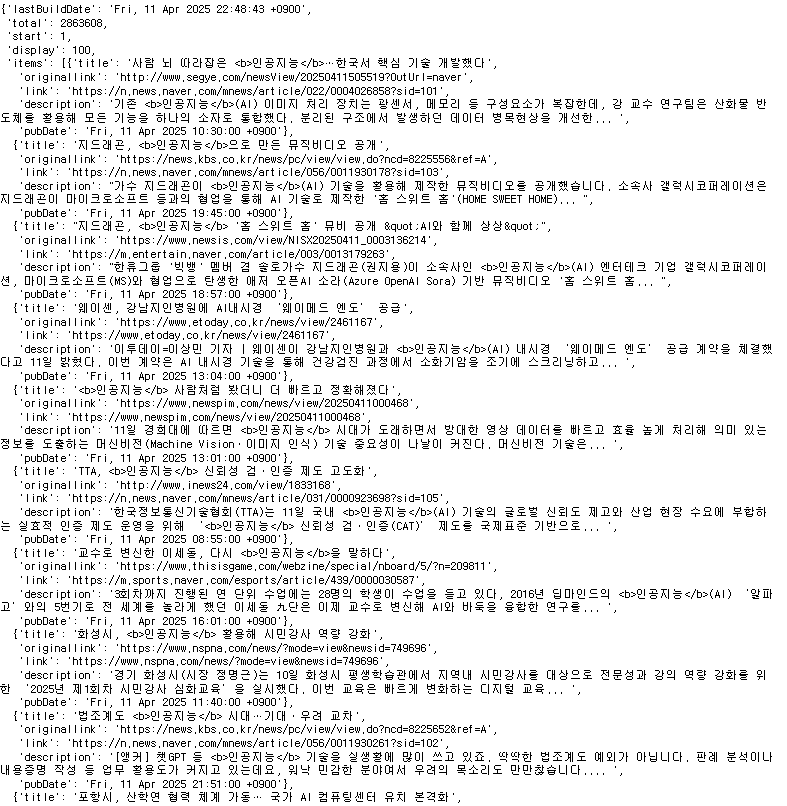

In [ ]:
response_blog[0]

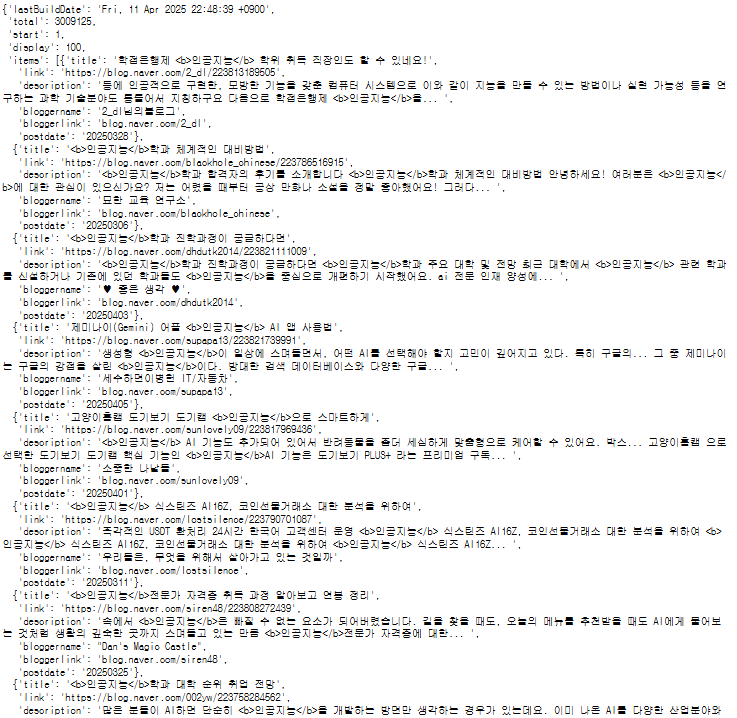

In [47]:
final_result_blog = {}
for page in response_blog[:1]: # 한 페이지씩 꺼낸다. (기존 setdefault 반복문에서 for 반복문 하나 추가된 것)
    for item in page['items']:
        for key, value in item.items():
            final_result_blog.setdefault(key, []).append(value)

final_result_blog
print(len(final_result_blog['title']))

100


In [119]:
blog_df = pd.DataFrame(final_result_blog)
blog_df

,title,link,description,bloggername,bloggerlink,postdate
0,학점은행제 <b>인공지능</b> 학위 취득 직장인도 할 수 있네요!,https://blog.naver.com/2_dl/223813189505,"등에 인공적으로 구현한, 모방한 기능을 갖춘 컴퓨터 시스템으로 이와 같이 지능을 만...",2_dl님의블로그,blog.naver.com/2_dl,20250328
1,<b>인공지능</b>학과 체계적인 대비방법,https://blog.naver.com/blackhole_chinese/22378...,<b>인공지능</b>학과 합격자의 후기를 소개합니다 <b>인공지능</b>학과 체계적...,묘한 교육 연구소,blog.naver.com/blackhole_chinese,20250306
2,<b>인공지능</b> 전문가 자격증 취득방법,https://blog.naver.com/mago41/223808447841,"<b>인공지능</b> 전문가 자격증 취득방법 최근 몇 년 사이, <b>인공지능</b...",정인춤터,blog.naver.com/mago41,20250324
3,<b>인공지능</b> 스피커 종류 KT 기가지니4 스펙 요금제 알아보기(lg...,https://blog.naver.com/minsha321/223816637896,"&quot; &quot; <b>인공지능</b> 스피커, 어떤 제품을 선택해야 좋을까...",일해라 절해라,blog.naver.com/minsha321,20250331
4,<b>인공지능</b>전문가 자격증 취득 과정 알아보고 연봉 정리,https://blog.naver.com/siren48/223808272439,속에서 <b>인공지능</b>은 빠질 수 없는 요소가 되어버렸습니다. 길을 찾을 때도...,Dan's Magic Castle,blog.naver.com/siren48,20250325
...,...,...,...,...,...,...
1095,안산시평생학습관 <b>인공지능</b>실무업무활용,https://blog.naver.com/eduansan/223760524551,2025 안산시평생학습관 피움과정 <b>인공지능</b>실무업무활용 <b>인공지능</...,안산시평생학습관,blog.naver.com/eduansan,20250214
1096,[기업 탐방] 청소년이 생각하는 <b>인공지능</b>은? 궁금증 타파!,https://blog.naver.com/theimc2104/223574590933,활동 '청소년 <b>인공지능</b> 연구소' 기대 · 변화 · 불안 · 경쟁 · 편...,"AI 교육플랫폼, AI EDUTOM(에이아이에듀톰)",blog.naver.com/theimc2104,20240906
1097,"딥러닝, PID 제어 대체 가능할까? <b>인공지능</b>의 도전",https://blog.naver.com/dean4001/223741995156,"PID 제어, <b>인공지능</b> 만나다 100년 가까이 산업 자동화와 공정 관리...",고양이집사 리샤's 포스트 IT,blog.naver.com/dean4001,20250130
1098,"<b>인공지능</b>팩토리, 디지털 혁신기업 글로벌 성장 R바우처...",https://blog.naver.com/venturesquare_/22368739...,(주)<b>인공지능</b>팩토리(대표 김태영)는 유성구청과 협력해 온프레미스 환경에...,VentureSquare,blog.naver.com/venturesquare_,20241209


# 함수 처리하기

In [16]:
def json_unpack(all_data):
    final_result = {}
    for page in all_data: # 한 페이지씩 꺼낸다. (기존 setdefault 반복문에서 for 반복문 하나 추가된 것)
        for item in page['items']:
            for key, value in item.items():
                final_result.setdefault(key, []).append(value)
    df = pd.DataFrame(final_result)
    return df

In [9]:
import pandas as pd

# 각각 csv 다운로드

In [19]:
for jsons, cat in zip([response_blog, response_news, response_book],["blog", "news", "book"]):# 문자열 아님. 변수임.
    unpack_result = json_unpack(jsons)
    unpack_result.to_csv(f"naver_{cat}_result.csv", encoding="utf-8", index=False)

# 3개 카테고리 수집을 함수화하기

In [21]:
def naver_search(keyword, category):
    response_result = []
    page = 1
    start_num2 = 1
    while True:
        url = f"https://openapi.naver.com/v1/search/{category}.json"
        Client_Id = "_kWwMseeAybz6oDQo3EC"
        Client_Secret = "oWRhEifFRY"
        payload = dict(query=keyword, display=100, start = start_num2, sort="sim")
        headers = {"X-Naver-Client-Id": Client_Id,
               "X-Naver-Client-Secret": Client_Secret}
        r = requests.get(url, params=payload, headers=headers)
        print(r.url, end="\r")
        print(r.status_code, end="\r")
        response = r.json()
        total_pages = (response['total'] // 100) + 1
        
        response_result.append(response)
        
        if category == 'blog':
            response_blog.append(response)
        elif category == 'news':
            response_news.append(response)
        elif category == 'book':
            response_book.append(response)
        
        response_json3.append(response)
        if start_num2 == 1000:
            break
        if start_num2 < 901:
            start_num2 += 100
        elif start_num2 == 901:
            start_num2 += 99

        if page < total_pages:
            page += 1
        else:
            break
        time.sleep(0.1)
    
    return response_result

In [22]:
import time
keyword = input("검색할 키워드를 입력해 주세요")
for category in ['blog', 'news', 'book']:
    naver_search_result = naver_search(keyword, category)
    print(f"{category}_search_result: {len(naver_search_result)}")

검색할 키워드를 입력해 주세요인공지능
blog_search_result: 11com/v1/search/blog.json?query=%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5&display=100&start=1000&sort=sim
news_search_result: 11com/v1/search/news.json?query=%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5&display=100&start=1000&sort=sim
book_search_result: 11com/v1/search/book.json?query=%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5&display=100&start=1000&sort=sim


In [ ]:
def json_unpack(all_data):
    final_result = {}
    for page in all_data: # 한 페이지씩 꺼낸다. (기존 setdefault 반복문에서 for 반복문 하나 추가된 것)
        for item in page['items']:
            for key, value in item.items():
                final_result.setdefault(key, []).append(value)
    df = pd.DataFrame(final_result)
    return df

In [ ]:
import time
keyword = input("검색할 키워드를 입력해 주세요")
for category in ['blog', 'news', 'book']:
    naver_search_result = naver_search(category)
    result_df = json_unpack(naver_search_result)
    display(result_df)

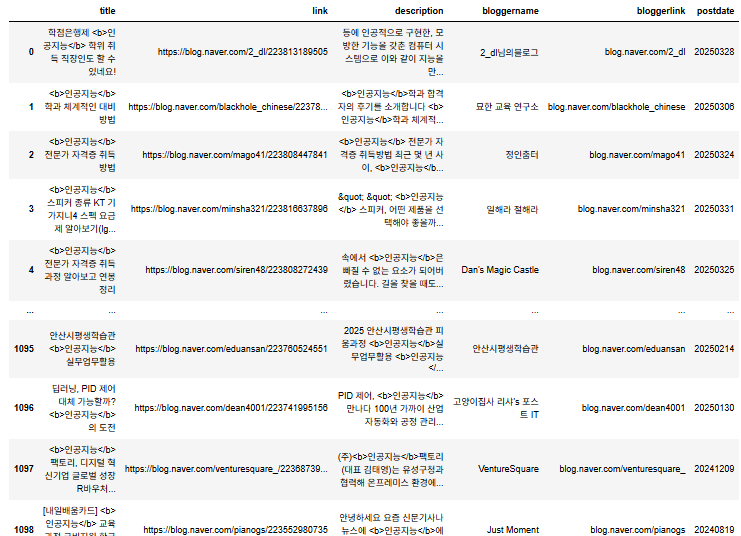

In [ ]:
import time
keyword = input("검색할 키워드를 입력해 주세요")
for category in ['blog', 'news', 'book']:
    naver_search_result = naver_search(category)
    result_df = json_unpack(naver_search_result)
    display(result_df)

In [ ]:
book_url = "https://openapi.naver.com/v1/search/book.json"
name = input("책 제목을 검색하세요.")
payload = {'query': name, 'display': 100}
headers = {"X-Naver-Client-Id" : "_kWwMseeAybz6oDQo3EC", "X-Naver-Client-Secret" : "oWRhEifFRY"}
r = requests.get(book_url, params=payload, headers=headers)
data = r.json()
data.items()

In [109]:
import pandas as pd

In [2]:
import requests
import pandas as pd

In [3]:
keyword = input("검색할 키워드를 입력해 주세요: ")
url = "https://openapi.naver.com/v1/search/book.json"
Client_ID = "_kWwMseeAybz6oDQo3EC"
Client_Secret = "oWRhEifFRY"
headers = {"X-Naver-Client-Id":Client_ID, "X-Naver-Client-Secret": Client_Secret}
payload = dict(query = keyword, display = 10, start = 1, sort = 'sim')

검색할 키워드를 입력해 주세요: 파이썬


In [31]:
payload

{'query': '파이썬', 'display': 10, 'start': 1, 'sort': 'sim'}

In [ ]:
r = requests.get(url, params=payload, headers=headers)
# get 방식으로 접속(requests)해라
# 파라미터는 payload에 담아라
# headers는 headers에 담아라 (API 사용 시 ID, PW 필요하기 때문)
# API ID/PW를 파라미터에 담을 것인지, 헤더에 담을 것인지는 사이트마다 다르다.
# 따라서, API가이드를 읽고 해석할 수 있는 것이 핵심이다.
print(url)
print(r.status_code)
data = r.json()
data
result_df = json_unpack(data)
result_df

In [5]:
def json_unpack(data):
    result = {}
    for item in data['items']:
        for key, value in item.items():
            result.setdefault(key, []).append(value)
    df = pd.DataFrame(result)
    return df

In [38]:
keyword = input("검색할 키워드를 입력해 주세요: ")

검색할 키워드를 입력해 주세요: 파이썬


In [7]:
keyword = input("검색할 키워드를 입력해 주세요: ")
url = "https://openapi.naver.com/v1/search/book.json"
Client_ID = "_kWwMseeAybz6oDQo3EC"
Client_Secret = "oWRhEifFRY"
headers = {"X-Naver-Client-Id":Client_ID, "X-Naver-Client-Secret": Client_Secret}
payload = dict(query = keyword, display = 100, start = 1, sort = 'sim')
r = requests.get(url, params=payload, headers=headers)
# print(r.url)
# print(r.status_code)
page = round(int(data['total'])/100) + 1
data = r.json()
print("전체 검색 데이터 수: ", data['total'], "검색할 페이지수: ", (int(data['total'])/100) + 1)

검색할 키워드를 입력해 주세요: 파이썬
전체 검색 데이터 수:  1113 검색할 페이지수:  12.13


In [ ]:
result = {}
for i in data['items']:
    for key, value in i.items():
        result.setdefault(key, []).append(value)
print(result)

In [ ]:
df = pd.DataFrame(data)
df

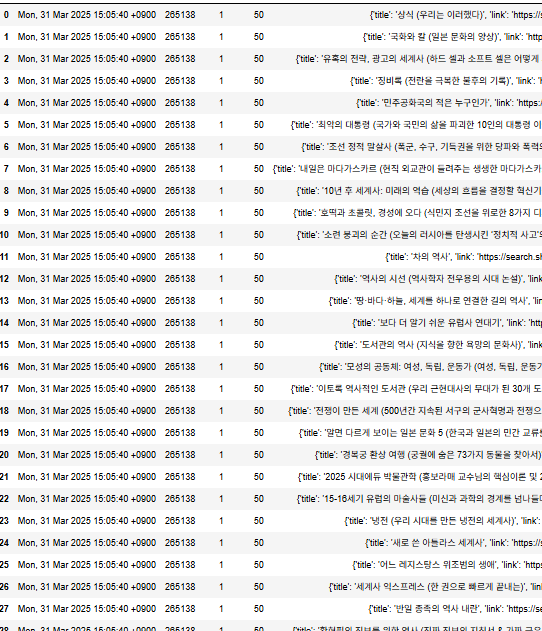

In [19]:
df = pd.DataFrame(result)

In [20]:
df

,title,link,image,author,discount,publisher,pubdate,isbn,description
0,"혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임,...",https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_528593...,문현일,23400,한빛미디어,20250214,9791169213271,“파이썬을 배워서 어디에 활용할 수 있을지 궁금했나요?”\n나의 신용카드 내역 분석...
1,혼자 공부하는 파이썬 (1:1 과외하듯 배우는 프로그래밍 자습서),https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_325076...,윤인성,19800,한빛미디어,20220601,9791162245651,혼자 해도 충분하다! 1:1 과외하듯 배우는 파이썬 프로그래밍 자습서\n\n『혼자 ...
2,Do it! 점프 투 파이썬 (중학생도 첫날부터 실습하는 초고속 입문서),https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_403540...,박응용,19800,이지스퍼블리싱,20230615,9791163034735,프로그래밍 분야 8년 연속 베스트셀러!\n《Do it! 점프 투 파이썬》 전면 개정...
3,밑바닥부터 시작하는 딥러닝 1(리마스터판) (파이썬으로 익히는 딥러닝 이론과 구현),https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_526155...,사이토 고키,23400,한빛미디어,20250124,9791169213387,딥러닝 분야 부동의 베스트셀러!\n머리로 이해하고 손으로 익히는 가장 쉬운 딥러닝 ...
4,50개의 프로젝트로 완성하는 파이썬 업무 자동화 (프로젝트 따라하기로 업무 자동화 ...,https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_537377...,오토코더,19800,위즈앤북(Wiznbook),20250317,9791198685353,ㆍ퀴즈와 QR 코드 생성부터 나만의 음성 비서 제작까지 다양한 프로젝트 대공개!\n...
...,...,...,...,...,...,...,...,...,...
95,"파이썬 매일 코딩 (매일 10분, 50가지 연습 문제로 키우는 파이썬 코딩 실력!)",https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_324600...,루벤 M. 러너,19800,길벗,20211130,9791165217884,능숙한 파이썬 프로그래머가 되기 위한 지름길!\n다양한 파이썬 문제를 풀어보며 프로...
96,마케터의 파이썬 (코딩의 C도 모르는 우리들을 위한 맞춤 프로그래밍 가이드),https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_324903...,정희석,19800,e비즈북스,20220126,9791157832361,코딩의 첫 허들을 성공적으로 넘는 마케터가 되자!\n\n파이썬 관련 강의와 도서는 ...
97,파이썬 알고리즘,https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_324907...,최영규,24840,생능출판,20210128,9788970504797,현대 사회를 살아가고 있는 우리에게 ‘알고리즘’은 더 이상 낯선 단어가 아닙니다. ...
98,시간순삭 파이썬 (당신의 1분 1초를 아껴줄),https://search.shopping.naver.com/book/catalog...,https://shopping-phinf.pstatic.net/main_324837...,천인국^정영민^최자영,22000,생능북스,20200827,9788970504650,이 책은 프로그래밍을 처음 시작하거나 너무 어려워 기초부터 다시 배우고 싶은 학습자...


In [60]:
for i in range(page + 1):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12


In [ ]:
result_df

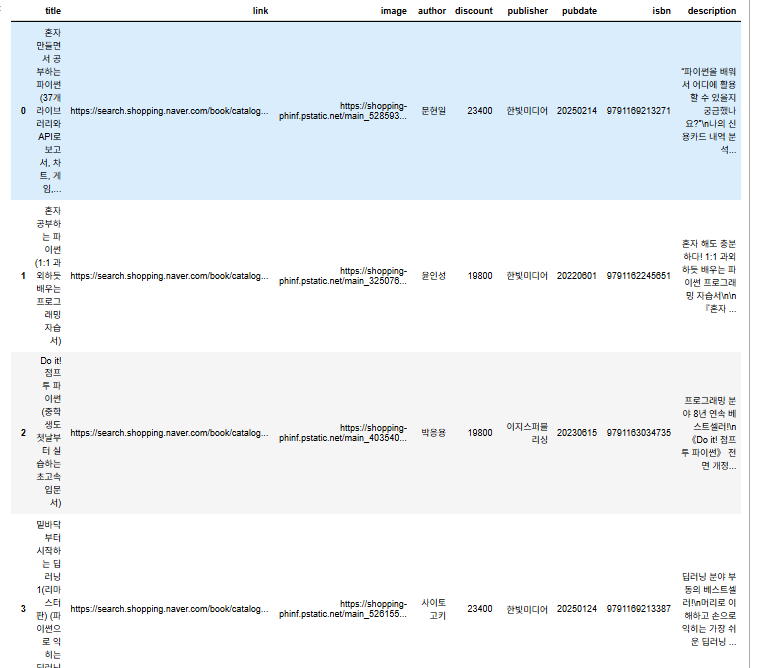

# 네이버 API로 검색한 결과 최대한 가져오기

* 1회 네이버 서버에 요청
* 응답에서 total을 찾아서 display로 나누어 총 반복할 페이지 산출
* 반복문 작성 및 종료 조건 설정
* start가 1, 101, 201, 301 처럼 변경되어야 함. start의 max값은 1000
* 1페이지 결과를 데이터 프레임으로 만들고 리스트에 append
* 반복이 끝난 후 리스트에 append된 데이터 프레임을 1개로 합침

In [ ]:
keyword = input("검색할 키워드를 입력해 주세요: ")

In [98]:
all_data = []

In [85]:
total_pages = (int(data['total'])//100) + 1

total_pages

12

In [99]:
start = 101
for page in range(total_pages):
    print(f"{page+1} / {total_pages} 수집중", end="\r")
    url = "https://openapi.naver.com/v1/search/book.json"
    Client_ID = "_kWwMseeAybz6oDQo3EC"
    Client_Secret = "oWRhEifFRY"
    headers = {"X-Naver-Client-Id":Client_ID, "X-Naver-Client-Secret": Client_Secret}
    payload = dict(query = keyword, display = 100, start = start, sort = 'sim')
    r = requests.get(url, params=payload, headers=headers)
    print(r.url)
    print(r.status_code)
    data = r.json()
    n_data = data['total']
    total_pages = (int(data['total'])//100) + 1
#     print("전체 검색 데이터 수: ", n_data, "검색할 페이지수: ", total_pages)
    result_df = json_unpack(data)
    all_data.append(result_df)
    if start == 1000:
        break
    elif start < 901:
        start += 100
    elif start == 901:
        start += 99

https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=101&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=201&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=301&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=401&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=501&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=601&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=701&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=801&sort=sim
200
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&

In [101]:
len(all_data)

10

In [ ]:
finall_

In [ ]:
result_df

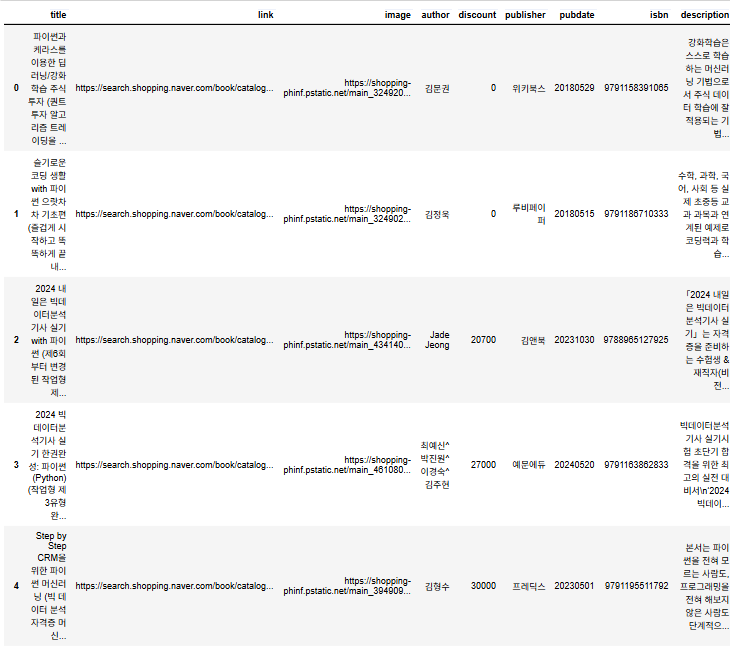

# While 문으로 데이터 모두 가져오기

In [107]:
keyword = input("검색할 키워드를 입력해 주세요: ")

검색할 키워드를 입력해 주세요: 파이썬


In [111]:
all_data2 = []
start = 1
while True:
    url = "https://openapi.naver.com/v1/search/book.json"
    Client_ID = "_kWwMseeAybz6oDQo3EC"
    Client_Secret = "oWRhEifFRY"
    headers = {"X-Naver-Client-Id" : Client_ID, "X-Naver-Client-Secret": Client_Secret}
    payload = dict(query = keyword, display = 100, start = start, sort = 'sim')
    r = requests.get(url, params=payload, headers=headers)
    print(r.url)
    print(r.status_code)
    data = r.json()
    n_data = data['total']
    total_pages = (int(data['total'])//100) + 1
    print("전체 검색 데이터 수: ", n_data, "검색할 페이지수: ", total_pages)
    result_df = json_unpack(data)
    all_data2.append(result_df)
    if start == 1000:
        break
    if start < 901:
        start += 100
    elif start == 901:
        start += 99

https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=1&sort=sim
200
전체 검색 데이터 수:  1113 검색할 페이지수:  12
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=101&sort=sim
200
전체 검색 데이터 수:  1113 검색할 페이지수:  12
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=201&sort=sim
200
전체 검색 데이터 수:  1113 검색할 페이지수:  12
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=301&sort=sim
200
전체 검색 데이터 수:  1113 검색할 페이지수:  12
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=401&sort=sim
200
전체 검색 데이터 수:  1113 검색할 페이지수:  12
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=501&sort=sim
200
전체 검색 데이터 수:  1113 검색할 페이지수:  12
https://openapi.naver.com/v1/search/book.json?query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&display=100&start=601&sort=sim
200

In [ ]:
len

In [ ]:
final_result2 = pd.concat(all_data2)
final_result2 = final_result2.reset_index(drop=True)
final_result2

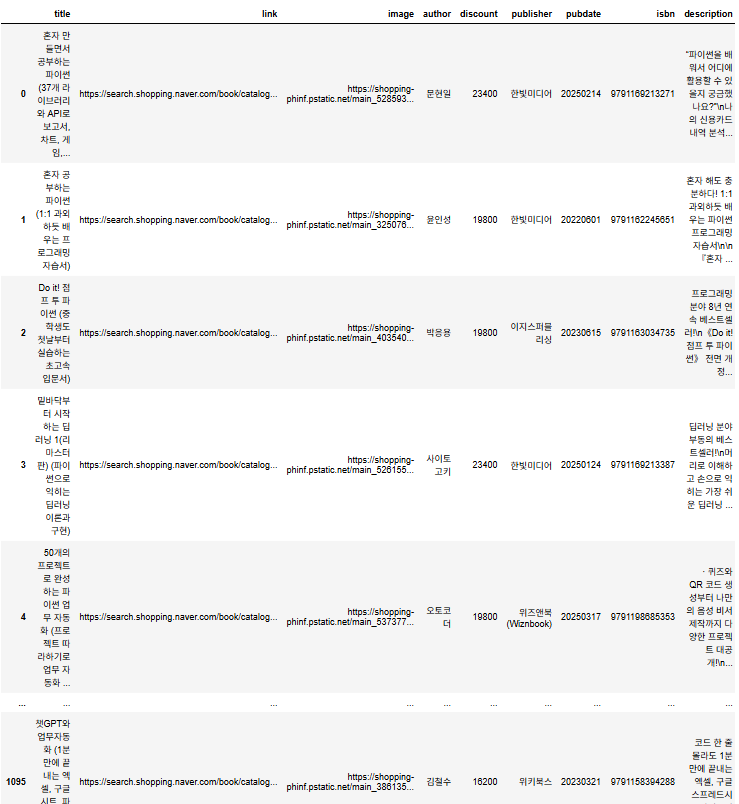

In [113]:
final_result2.to_csv("네이버검색_책_파이썬.csv", encoding="utf-8-sig", index = False)

# 뉴스, 블로그, 책 한번에 검색해서 저장하기

In [120]:
keyword = input("검색 키워드를 입력해 주세요.")

검색 키워드를 입력해 주세요.핀테크


In [51]:
def json_unpack(data):
    result = {}
    for item in data['items']:
        for key, value in item.items():
            result.setdefault(key, []).append(value)
    df = pd.DataFrame(result)
    return df

In [53]:
keyword = input("검색 키워드를 입력해 주세요.")
all_data3 = []

start = 1
for category in ["blog", "news", "book"]:
    start=1
    while True:
        url = f"https://openapi.naver.com/v1/search/{category}.json"
        Client_ID = "_kWwMseeAybz6oDQo3EC"
        Client_Secret = "oWRhEifFRY"
        headers = {"X-Naver-Client-Id" : Client_ID, "X-Naver-Client-Secret": Client_Secret}
        payload = dict(query = keyword, display = 100, start = start, sort = 'sim')
        r = requests.get(url, params=payload, headers=headers)
        print(r.url)
        print(r.status_code)
        data = r.json()
        n_data = data['total']
        total_pages = (int(data['total'])//100) + 1
        print("전체 검색 데이터 수: ", n_data, "검색할 페이지수: ", total_pages)
        result_df = json_unpack(data)
        all_data3.append(result_df)
        if start == 1000:
            break
        if start < 901:
            start += 100
        elif start == 901:
            start += 99
final_result3 = pd.concat(all_data3)
final_result3 = final_result3.reset_index(drop=True)
final_result3

검색 키워드를 입력해 주세요.핀테크
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=1&sort=sim
200
전체 검색 데이터 수:  457899 검색할 페이지수:  4579
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=101&sort=sim
200
전체 검색 데이터 수:  457900 검색할 페이지수:  4580
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=201&sort=sim
200
전체 검색 데이터 수:  457900 검색할 페이지수:  4580
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=301&sort=sim
200
전체 검색 데이터 수:  457900 검색할 페이지수:  4580
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=401&sort=sim
200
전체 검색 데이터 수:  457900 검색할 페이지수:  4580
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C%ED%81%AC&display=100&start=501&sort=sim
200
전체 검색 데이터 수:  457900 검색할 페이지수:  4580
https://openapi.naver.com/v1/search/blog.json?query=%ED%95%80%ED%85%8C

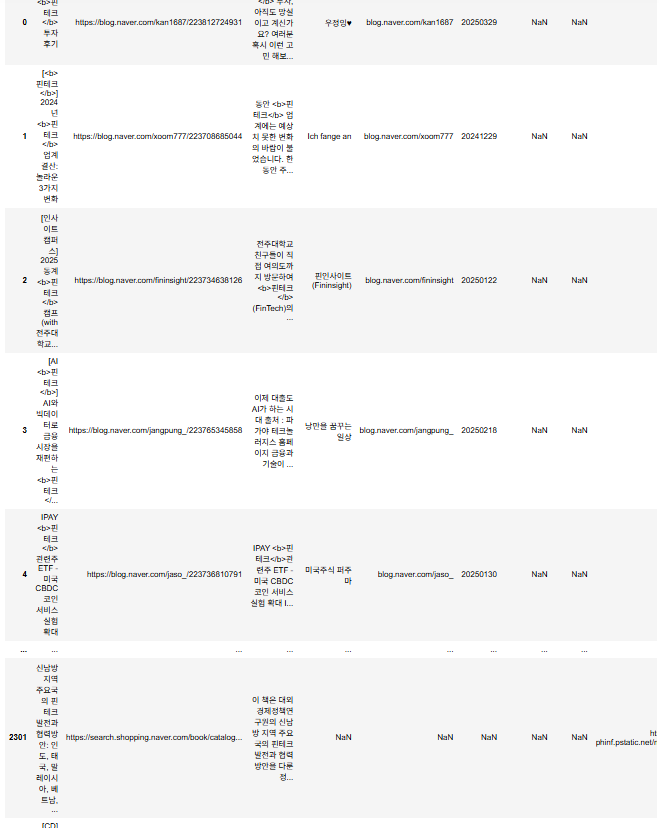